In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
df = pd.read_csv("/content/spam.csv",encoding='latin-1')

In [96]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [98]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [99]:
df.drop(columns = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace = True)

In [100]:
df.rename(columns = {"v1": "Target","v2": "Text"},inplace =True)

In [101]:
df["Text"][1]

'Ok lar... Joking wif u oni...'

In [102]:
df["Target"].value_counts()

,count
Target,
ham,4825
spam,747


In [103]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Target"] = le.fit_transform(df["Target"])
df["Target"].unique()

array([0, 1])

In [104]:
df.drop_duplicates(keep = "first",inplace = True)

In [105]:
df.shape

(5169, 2)

<Axes: ylabel='count'>

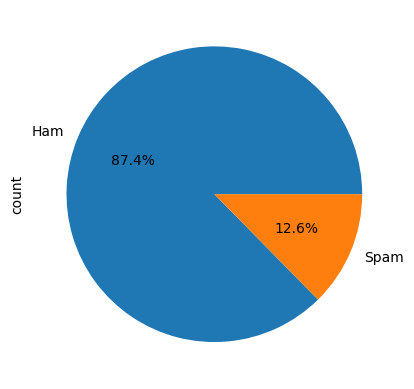

In [106]:
df["Target"].value_counts().plot(kind = "pie",labels = ["Ham","Spam"],autopct = "%0.1f%%")

In [107]:
! pip install nltk

In [108]:
import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [109]:
df

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [110]:
df["num_chars"] = df["Text"].apply(len)

In [111]:
df["num_words"] = df["Text"].apply(lambda x : len(nltk.word_tokenize(x)))
df["num_sent"] = df["Text"].apply(lambda x : len(nltk.sent_tokenize(x)))

In [112]:
df.head()

,Target,Text,num_chars,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


## Data Precprocessing

- lowercase
- Tokenization
- Removing special chars
- removing stopwords and punctuation
- steaming (converting any wordinto its root form)

In [113]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [114]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [115]:
def transform_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text)
  y = []

  for i in text:
    if i.isalnum():
      y.append(i)
  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words("english") and i not in string.punctuation:
      y.append(i)
  t = y[:]
  y.clear()
  for i in t:
    y.append(ps.stem(i))
  return " ".join(y)

In [116]:
transform_text("did you like my presentation on machine learning?")

'like present machin learn'

In [117]:
df["new_col"] = df["Text"].apply(transform_text)

In [118]:
! pip install wordcloud

In [119]:
from wordcloud import WordCloud

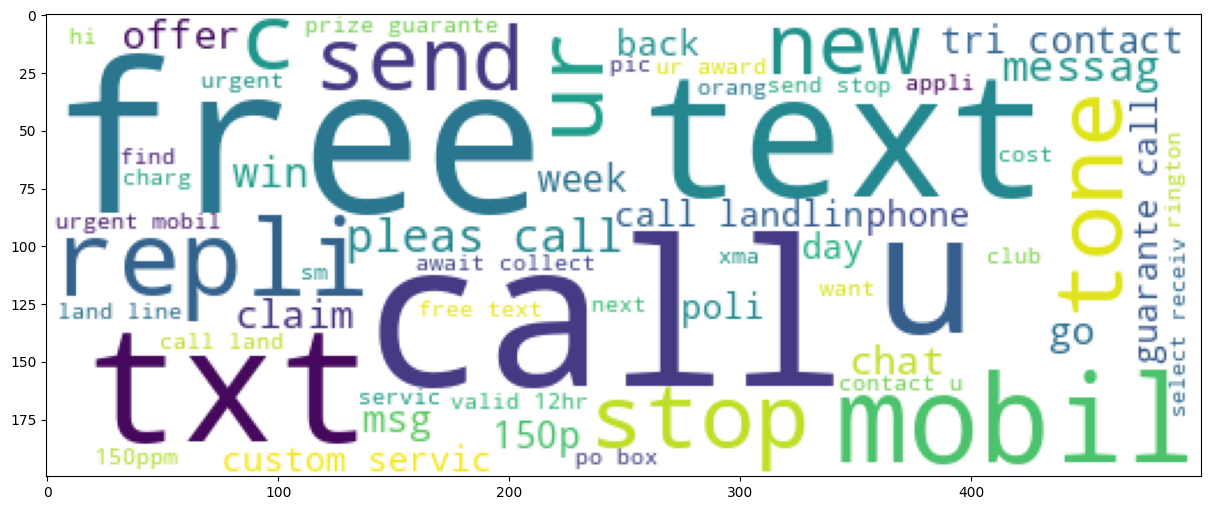

In [124]:
wc = WordCloud(width = 500, height = 200, min_font_size = 10, background_color = "white")
spam_word_cloud = wc.generate(df[df["Target"] == 1]["new_col"].str.cat(sep = " "))
plt.figure(figsize = (20,6))
plt.imshow(spam_word_cloud)

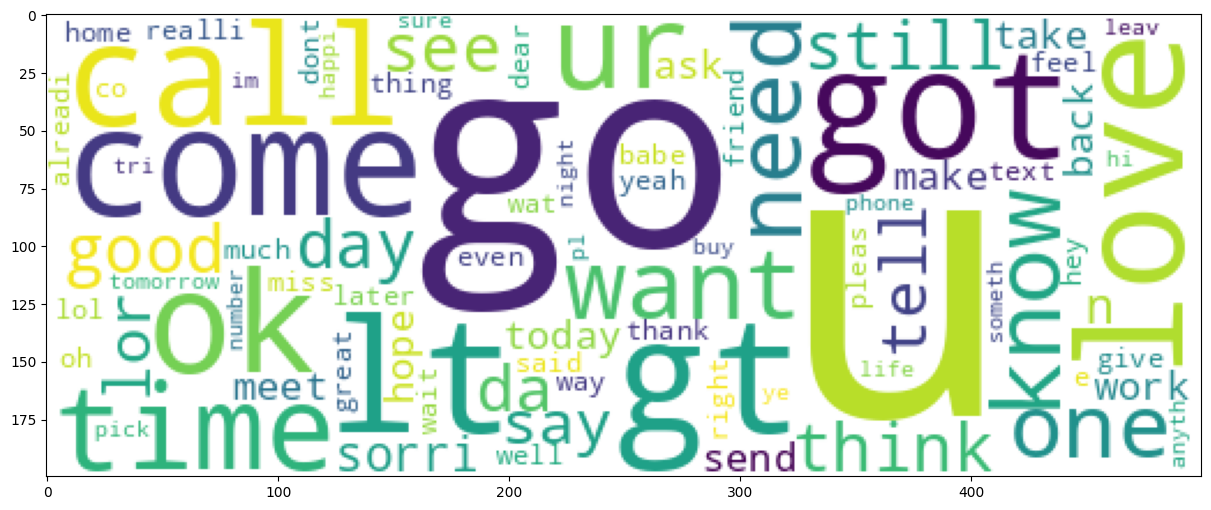

In [123]:
ham_word_cloud = wc.generate(df[df["Target"] == 0]["new_col"].str.cat(sep = " "))
plt.figure(figsize = (20,6))
plt.imshow(ham_word_cloud)

## CountVectorizer

It converts a collection of text doxuments into a matrix of token (word)
counts. It tokenizes the test, builds vocabulary of known words andcounts how many times each word appears in a document

In [126]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
cv = CountVectorizer()
tfidf = TfidfTransformer()

In [127]:
x_count = cv.fit_transform(df["new_col"])
x = tfidf.fit_transform(x_count).toarray()

In [129]:
type(x_count)

scipy.sparse._csr.csr_matrix

In [130]:
y  = df["Target"].values

In [131]:
from sklearn.model_selection import train_test_split as tts

In [143]:
x_train,x_test,y_train,y_test = tts(x,y,test_size = 0.2,random_state=42)

In [144]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [145]:
mnb = MultinomialNB()
mnb.fit(x_train,y_train)
y_pred = mnb.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))

Accuracy 0.9613152804642167


In [148]:
def predict_prob(message):
  transformed = transform_text(message)
  vector_input = cv.transform([transformed])
  tfidf_input = tfidf.transform(vector_input)

  prob = mnb.predict(tfidf_input)[0]
  if prob == 0:
    return "Ham"
  else:
    return "Spam"

In [150]:
predict_prob("i want to watch a movie")

'Ham'